In [6]:
# Libraries
import pyvisa                    # Communication (also install pyvisa-py or NI VISA)
import matplotlib.pyplot as plt  # Plots
import numpy as np               # Maths
import pandas as pd              # DataFrames
import time                      # Delays
from tqdm.notebook import tqdm   # Progress bars (use 'for i in tqdm(iter)')
import os                        # Used for determining platform
import sys                       # Used for local import setup
sys.path.append(r"../../")       # Used for local imports

In [7]:
from Utilities.SetupLogging import setupLogging
logger = setupLogging()

In [8]:
from Devices.SRS import SR850
from Devices.Coherent import SapphireLP, CUBE
from Devices.PM100 import PM100
from Devices.Keithley import SourceMeter2400
from Devices.QuantumDesign import PPMS

In [9]:
rm = pyvisa.ResourceManager()

lockin = SR850(rm, 'GPIB1::14::INSTR')
laser = CUBE(rm, address='ASRL1::INSTR')
pm = PM100(rm, 'USB0::0x1313::0x8078::P0017770::INSTR', attName='ppms-tap')
sm = SourceMeter2400(rm, sn='04085563')
ppms = PPMS("8fvfvd3.dhcp.nd.edu")

In [18]:
n = 10
powers = np.linspace(2, 60, n)

powers_sample = []
temps = []
res2 = []
res3 = []

for power in tqdm(powers):
    laser.power = power
    time.sleep(3)
    
    while not ppms.isSteady(temp=True):
        time.sleep(1)

    temps.append(ppms.getTemperature()[0])
    powers_sample.append(pm.power*1e3)
    res2.append(ppms.getResistance(2)[0])
    res3.append(ppms.getResistance(3)[0])

  0%|          | 0/10 [00:00<?, ?it/s]

In [21]:
laser.power = 10

In [22]:
print(pm.power*1e3)

1.463286654866986


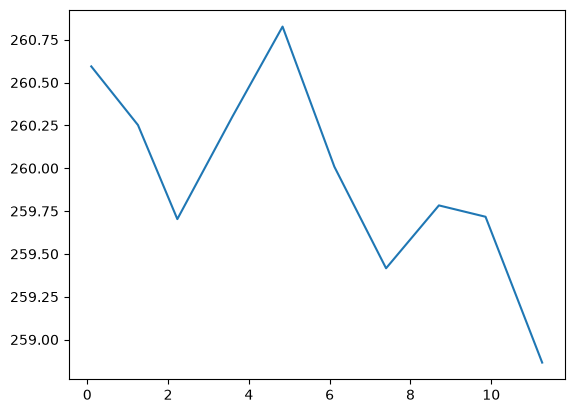

In [19]:
plt.plot(powers_sample, res2)

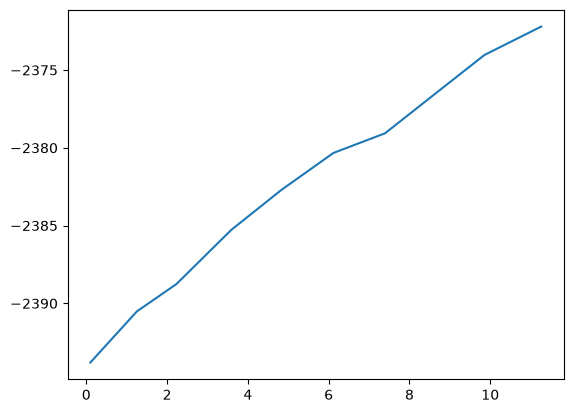

In [20]:
plt.plot(powers_sample, res3)